# **GOALS** : **Membangun Model Prediksi Risiko Stunting yang Diperkuat Data Eksternal**
---
**Input**

* File Excel mentah Yayasan (dibersihkan sendiri dari nol)
* Dataset eksternal hasil pencarian mandiri (misal dataset stunting Kaggle dengan fitur gender/ekonomi/riwayat ASI, atau tabel kurva pertumbuhan WHO)
---
**Proses**
* Cleaning & klasifikasi status gizi mandiri (independen, tidak memakai hasil Kelompok 1)
* Eksplorasi dataset eksternal: fitur tambahan apa yang tersedia dan apakah relevan
* Bangun model klasifikasi risiko, divalidasi/diperkaya dengan data eksternal, diterapkan ke data Yayasan
* Simulasi “what-if”: proyeksi status gizi jika berat badan naik sekian kg dalam sekian bulan, memakai referensi kurva pertumbuhan WHO
* Evaluasi model & catat keterbatasan (ukuran data kecil, kesebandingan data eksternal)
---
**Output**
* Model prediksi + dokumentasi cara & alasan pemakaian data eksternal
* Skor risiko per anak + simulasi proyeksi pertumbuhan untuk beberapa skenario (Opsional)
* Catatan reflektif tingkat kepercayaan model mengingat keterbatasan data

# **Checkpoint 0 - Business & Data Understanding**

* **Identifikasi tujuan proyek**
* **Data Quality Assessment** : Memeriksa missing value, duplikasi, inkonsistensi data, outlier, kesalahan format tanggal, dan validitas nilai antropometri
* **Studi Literatur**

\**Catatan**

Dataset hanya terdiri dari **nama anak, tanggal lahir, berat badan, dan tinggi badan**,

**Suggestion tambah data:**  
* Jenis kelamin,
* Riwayat ISPA
* Riwayat Diare
* Berat & Panjang lahir,
* ASI eksklusif (Ya/Tidak),
* MP-ASI (Ya/Tidak)
* Imunisasi (Ya/Tidak)
* Ketersediaan air bersih termasuk konsumsi air minum
* Tingkat pendidikan Ibu
* Pemeriksaan ANC
* Status ekonomi
* Tinggi badan Ibu

**Sumber**
1. Factors Associated With Child Stunting, Wasting, and Underweight
in 35 Low- and Middle-Income Countries (https://pubmed.ncbi.nlm.nih.gov/32320037/)
2. Improved sanitation is associated with reduced child stuntingamongst Indonesian children under 3 years of age (https://onlinelibrary.wiley.com/doi/epdf/10.1111/mcn.12741)
3. Effect of parental formal education on risk of child stunting in Indonesia and Bangladesh: a cross-sectional study (https://www.thelancet.com/journals/lancet/article/PIIS0140-6736(08)60169-5/abstract)
4. A review of child stunting determinants in Indonesia (https://onlinelibrary.wiley.com/doi/epdf/10.1111/mcn.12617)
5. Permenkes Nomor 2 Tahun 2020 tentang Standar Antropometri Anak (https://peraturan.bpk.go.id/Details/152505/permenkes-no-2-tahun-2020)

**DATASET**

Project ini menggunakan **dummy dataset** untuk sementara waktu sampai dengan **real dataset** disediakan oleh yayasan

# **Checkpoint 1 & 2 - Data Preparation**

* **Data Cleaning** : Membersihkan missing value, duplikasi, kesalahan input, konversi tipe data, dan validasi nilai berat serta tinggi badan
* **Feature Engineering** : Menghitung umur (bulan), imt, Height-for-Age Z-score (HAZ), kelompok umur, dan status stunting
* **Data Transformation** : Normalisasi atau standarisasi data (jika diperlukan), encoding variabel kategorik
* **Validasi Dataset** : Memastikan seluruh fitur telah dihitung dengan benar dan siap digunakan

**Indikator :**
* HAZ (TB/U)
* WAZ (BB/U)
* WHZ (BB/TB)
* BAZ (IMT/U)

**Create dummy dataset**


In [14]:
# # Mounting drive to connect dataset
# from google.colab import drive
# drive.mount('/content/drive')
# print(f"Mounted berhasil !")

# Mounting Folder Kerja
print(f"Mounting folder kerja")

import os
# os.chdir(r"C:\Users\ACER\Downloads\#Bootcamp DS\project_stunting_yim")
os.chdir(r"C:\Users\ADMIN\Downloads\#Bootcamp\project_stunting_yim\stunting")

print(f"Mounting berhasil !")

Mounting folder kerja
Mounting berhasil !


In [15]:
# Load library
# !pip install skimpy tableone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
print(f"Import library berhasil !")

Import library berhasil !


In [16]:
def clean_bb(s):
  bb = pd.to_numeric(
        s.str.replace(r"KG|kg|CM", "", regex=True)
        .str.replace(r"\,+", ".", regex=True)
        .str.strip(),
      errors="coerce"
  )
  return bb.fillna(bb.median()).round(2).astype("Float64")

def clean_tb(s):
  tb = pd.to_numeric(
        s.str.extract(r"^(\d+)",expand=False),
      errors="coerce"
  )
  return tb.fillna(tb.median()).round(2).astype("Float64")

def calculate_age(s):
  age = (pd.Timestamp.today().year - s.dt.year) * 12 + (pd.Timestamp.today().month - s.dt.month)
  return age.fillna(age.median()).round(2).astype("Float64")

def imt(s,p):
  imt = s / (p/100)**2
  return imt.fillna(imt.median()).round(2).astype("Float64")

# **Checkpoint 2,3,4 - Exploratory Data Analysis (EDA)**

* **Analisis Univariat** : Menghitung statistik deskriptif (mean, median, SD, minimum, maksimum, IQR) untuk setiap variabel
* **Analisis Bivariat** : Mengeksplorasi hubungan umur, berat, tinggi, imt, dan status stunting
* **Visualisasi Data** : Membuat histogram, boxplot, scatter plot, density plot, dan correlation matrix
* **Penyusunan Insight** : Menginterpretasikan pola, tren & karakteristik data


## **Deskripsi Dataset**

In [17]:
# Mengambil data dari gsheet
# sheet_id_stunting = "1TmvoVXhDdIBr00zF-Fd1bhBCCqINRUjwNs1HEKrDMFU"
# sheet_name_stunting = "dummy_dataset_stunting"
# url_df_dummy = f"https://docs.google.com/spreadsheets/d/{sheet_id_stunting}/gviz/tq?tqx=out:csv&sheet={sheet_name_stunting}"
# df_dummy = pd.read_csv(url_df_dummy)
# df_dummy.columns = df_dummy.columns.str.lower()

# sheet_id_who = "1cxMrO4WgfXR9Tnx1X9-NWAvAucNjoOjd"
# sheet_name_who = "WHO_reference"
# url_ref_who = f"https://docs.google.com/spreadsheets/d/{sheet_id_who}/gviz/tq?tqx=out:csv&sheet={sheet_name_who}"
# ref_who = pd.read_csv(url_ref_who)
# ref_who.columns = ref_who.columns.str.lower()

df_dummy = pd.read_csv("dummy_dataset_stunting.csv")
df_dummy.columns = df_dummy.columns.str.lower()

ref_who = pd.read_csv("who_length_height_for_age_reference_0_60_months.xlsx - WHO_reference.csv")
ref_who.columns = ref_who.columns.str.lower()

print(
    """
    Dataset ini merupakan dataset dummy/sintetis yang dibuat untuk keperluan pembelajaran dan pengembangan model Machine Learning dalam analisis risiko stunting pada anak.
    Dataset merepresentasikan data karakteristik anak, pengukuran antropometri, riwayat kesehatan, status imunisasi, serta informasi kesehatan maternal yang berkaitan dengan
    kondisi pertumbuhan anak.

    Setiap baris pada dataset merepresentasikan satu anak, sedangkan setiap kolom merepresentasikan karakteristik atau indikator kesehatan yang diamati.
    Variabel antropometri meliputi usia anak dalam bulan, berat badan, tinggi badan, dan BMI. Dataset juga mencakup beberapa variabel riwayat kesehatan
    seperti Acute Respiratory Infection (ARI), kelengkapan imunisasi, serta jumlah kunjungan Antenatal Care (ANC) selama masa kehamilan.

    Variabel status_stunting digunakan sebagai variabel target yang menggambarkan kategori status pertumbuhan anak, misalnya Normal, Stunted, Severely Stunted, dan Tall.
    Karena dataset ini bersifat dummy/sintetis, data tidak merepresentasikan individu atau kondisi kesehatan nyata dan tidak dapat digunakan untuk diagnosis klinis maupun
    pengambilan keputusan medis.

    Dataset ditujukan untuk simulasi proses Exploratory Data Analysis (EDA), statistical analysis, feature selection, classification modelling, model evaluation
    dan interpretasi risiko stunting
    """
)

print(f"Import data berhasil !")


    Dataset ini merupakan dataset dummy/sintetis yang dibuat untuk keperluan pembelajaran dan pengembangan model Machine Learning dalam analisis risiko stunting pada anak.
    Dataset merepresentasikan data karakteristik anak, pengukuran antropometri, riwayat kesehatan, status imunisasi, serta informasi kesehatan maternal yang berkaitan dengan
    kondisi pertumbuhan anak.

    Setiap baris pada dataset merepresentasikan satu anak, sedangkan setiap kolom merepresentasikan karakteristik atau indikator kesehatan yang diamati.
    Variabel antropometri meliputi usia anak dalam bulan, berat badan, tinggi badan, dan BMI. Dataset juga mencakup beberapa variabel riwayat kesehatan
    seperti Acute Respiratory Infection (ARI), kelengkapan imunisasi, serta jumlah kunjungan Antenatal Care (ANC) selama masa kehamilan.

    Variabel status_stunting digunakan sebagai variabel target yang menggambarkan kategori status pertumbuhan anak, misalnya Normal, Stunted, Severely Stunted, dan Tall.
    Karen

## **Preparation**

In [18]:
def calculate_haz(sex,age,height):
  z = height
  ref = ref_who.loc[(ref_who["age_months"] == age) & (ref_who["sex"] == sex)].iloc[0]
  l_val = ref["l"]
  m_val = ref["m"]
  s_val = ref["s"]
  haz = (((z/m_val)**l_val)-1)/(l_val*s_val)
  return haz.round(2)

def classify_stunting(haz):
  if haz < -3:
    return "Severely stunted"
  elif haz < -2:
    return "Stunted"
  elif haz <= 3:
    return "Normal"
  else:
    return "Tall"

print(f"Membuat function hitung & klasifikasi HAZ berhasil !")

Membuat function hitung & klasifikasi HAZ berhasil !


In [19]:
# Ubah variabel ke tipe kategorikal
df_dummy['anc_visits'] = df_dummy['anc_visits'].astype("category")
df_dummy['maternal_education'] = df_dummy['maternal_education'].astype("category")
df_dummy['maternal_marriage_age'] = df_dummy['maternal_marriage_age'].astype("category")
df_dummy['drinking_water_source'] = df_dummy['drinking_water_source'].astype("category")
df_dummy['clean_water_availability'] = df_dummy['clean_water_availability'].astype("category")
df_dummy['iodized_salt'] = df_dummy['iodized_salt'].astype("category")
df_dummy['complete_immunization'] = df_dummy['complete_immunization'].astype("category")
df_dummy['complementary_feeding'] = df_dummy['complementary_feeding'].astype("category")
df_dummy['exclusive_breastfeeding'] = df_dummy['exclusive_breastfeeding'].astype("category")
df_dummy['vitamin_a_consumption'] = df_dummy['vitamin_a_consumption'].astype("category")
df_dummy['skilled_birth_attendant'] = df_dummy['skilled_birth_attendant'].astype("category")
df_dummy['history_diarrhea'] = df_dummy['history_diarrhea'].astype("category")
df_dummy['history_ari'] = df_dummy['history_ari'].astype("category")
df_dummy['sex'] = df_dummy['sex'].astype("category")
df_dummy['wealth_index'] = df_dummy['wealth_index'].astype("category")
df_dummy['sanitation_facility'] = df_dummy['sanitation_facility'].astype("category")

# df_dummy.select_dtypes(exclude="number").iloc[:,1:18].columns
# df_dummy.select_dtypes(include="number").columns
numerical_columns = ['birth_weight_g', 'birth_length_cm', 'measurement_weight_g',
       'measurement_height_cm', 'measurement_bmi', 'measurement_age_months',
       'maternal_height_cm', 'haz_score']
categorical_columns = ['sex','cat_age','history_ari', 'history_diarrhea', 'skilled_birth_attendant',
       'vitamin_a_consumption', 'exclusive_breastfeeding',
       'complementary_feeding', 'complete_immunization', 'iodized_salt',
       'clean_water_availability', 'drinking_water_source',
       'maternal_marriage_age', 'maternal_education', 'anc_visits',
       'wealth_index', 'sanitation_facility']
columns = numerical_columns + categorical_columns

print(f"Convert variabel berhasil !")

Convert variabel berhasil !


In [20]:
# Menentukan status stunting berdasarkan nilai HAZ WHO
df_dummy = (
  df_dummy
  .assign(
    haz_score = lambda x: x.apply(
      lambda y: calculate_haz(
          y["sex"],
          y["measurement_age_months"],
          y["measurement_height_cm"]
      ), axis=1
    ),
    stunting_status = lambda x: x["haz_score"].apply(classify_stunting),
    cat_age = lambda x: pd.cut(
        x["measurement_age_months"],
        bins=[0, 25, 61, float("inf")],
        labels=["0-24", "25-60", ">60"],
        right=False
    ).astype("category")
  )
)

# Simpan data yang sudah dibersihkan
df_dummy.to_csv("dummy_dataset_cleaned.csv", index=False)
print("Data bersih tersimpan!")

Data bersih tersimpan!


In [21]:
# Deskripsi Dataset
print("="*50)
print("DUMMY DATASET")
print("="*50)
print(f"Total data: {len(df_dummy)} anak")
print(f"Jumlah missing :\n{df_dummy.isna().sum()}")
print("="*50)
df_dummy[numerical_columns].describe().round(2).T

DUMMY DATASET
Total data: 121999 anak
Jumlah missing :
child_id                    0
birth_weight_g              0
birth_length_cm             0
measurement_weight_g        0
measurement_height_cm       0
measurement_bmi             0
measurement_age_months      0
sex                         0
history_ari                 0
history_diarrhea            0
skilled_birth_attendant     0
vitamin_a_consumption       0
exclusive_breastfeeding     0
complementary_feeding       0
complete_immunization       0
iodized_salt                0
clean_water_availability    0
drinking_water_source       0
maternal_height_cm          0
maternal_marriage_age       0
maternal_education          0
anc_visits                  0
wealth_index                0
sanitation_facility         0
haz_score                   0
stunting_status             0
cat_age                     0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
birth_weight_g,121999.0,3077.85,817.83,1657.00,2374.98,3077.66,3782.02,4500.00
birth_length_cm,121999.0,49.44,3.53,43.30,46.38,49.44,52.47,55.60
measurement_weight_g,121999.0,10148.28,4587.57,2200.00,6165.04,10164.41,14114.72,18120.00
measurement_height_cm,121999.0,88.66,17.30,40.01,77.00,89.80,101.20,128.00
measurement_bmi,121999.0,14.81,10.68,1.42,7.58,12.51,18.71,108.82
measurement_age_months,121999.0,30.17,17.57,0.00,15.00,30.00,45.00,60.00
maternal_height_cm,121999.0,152.47,10.07,135.00,143.80,152.46,161.16,170.00
haz_score,121999.0,0.01,2.72,-7.04,-2.22,0.00,2.20,8.79


## **Time Series**


In [22]:
import numpy as np

np.random.seed(42)

N_BULAN = 5
n_anak = len(df_dummy) // N_BULAN

df_anak_unik = df_dummy.iloc[:n_anak].reset_index(drop=True)

kolom_tetap = [
    "child_id", "birth_weight_g", "birth_length_cm", "sex",
    "history_ari", "history_diarrhea", "skilled_birth_attendant",
    "vitamin_a_consumption", "exclusive_breastfeeding", "complementary_feeding",
    "complete_immunization", "iodized_salt", "clean_water_availability",
    "drinking_water_source", "maternal_height_cm", "maternal_marriage_age",
    "maternal_education", "anc_visits", "wealth_index", "sanitation_facility",
    "cat_age"
]
kolom_tetap = [k for k in kolom_tetap if k in df_anak_unik.columns]

def calculate_haz(sex, age, height):
    z = height
    age = int(round(age))
    match = ref_who.loc[(ref_who["age_months"] == age) & (ref_who["sex"] == sex)]
    if match.empty:
        return np.nan
    ref = match.iloc[0]
    l_val, m_val, s_val = ref["l"], ref["m"], ref["s"]
    haz = (((z / m_val) ** l_val) - 1) / (l_val * s_val)
    return round(haz, 2)

def classify_stunting(haz):
    if pd.isna(haz):
        return "Unknown"
    if haz < -3:
        return "Severely stunted"
    elif haz < -2:
        return "Stunted"
    elif haz <= 3:
        return "Normal"
    else:
        return "Tall"

# --- BARU: laju pertumbuhan disesuaikan umur (bukan flat) ---
def get_laju_pertumbuhan(umur_bulan):
    if umur_bulan < 6:
        mean_tinggi, mean_berat = 2.0, 0.6
    elif umur_bulan < 12:
        mean_tinggi, mean_berat = 1.2, 0.4
    elif umur_bulan < 24:
        mean_tinggi, mean_berat = 0.9, 0.25
    elif umur_bulan < 36:
        mean_tinggi, mean_berat = 0.7, 0.2
    else:
        mean_tinggi, mean_berat = 0.5, 0.15
    laju_tinggi = np.random.normal(loc=mean_tinggi, scale=mean_tinggi * 0.3)
    laju_berat  = np.random.normal(loc=mean_berat, scale=mean_berat * 0.3)
    return laju_tinggi, laju_berat

umur_maks = ref_who["age_months"].max()

records = []
for _, row in df_anak_unik.iterrows():
    umur_awal   = row["measurement_age_months"]
    tinggi_awal = row["measurement_height_cm"]
    berat_awal  = row["measurement_weight_g"] / 1000
    sex         = row["sex"]

    for bulan in range(1, N_BULAN + 1):
        umur = umur_awal + (bulan - 1)
        if umur > umur_maks:
            continue

        # --- BARU: pakai laju sesuai umur, bukan angka flat ---
        laju_tinggi, laju_berat = get_laju_pertumbuhan(umur_awal)

        tinggi = tinggi_awal + laju_tinggi * (bulan - 1)
        berat_kg = berat_awal + laju_berat * (bulan - 1)

        rec = {k: row[k] for k in kolom_tetap}
        rec.update({
            "bulan_ke": bulan,
            "measurement_age_months": umur,
            "measurement_height_cm": round(tinggi, 1),
            "measurement_weight_g": round(berat_kg * 1000, 0),
            "measurement_bmi": round(berat_kg / ((tinggi / 100) ** 2), 2),
        })
        records.append(rec)

df_timeseries = pd.DataFrame(records)

df_timeseries["haz_score"] = df_timeseries.apply(
    lambda r: calculate_haz(r["sex"], r["measurement_age_months"], r["measurement_height_cm"]),
    axis=1
)
df_timeseries["stunting_status"] = df_timeseries["haz_score"].apply(classify_stunting)

print(f"Total baris time series: {len(df_timeseries)}")
print(f"Total anak unik: {df_timeseries['child_id'].nunique()}")
print(f"Baris yang dilewati (umur > {umur_maks} bulan): {n_anak * N_BULAN - len(df_timeseries)}")

Total baris time series: 121902
Total anak unik: 24399
Baris yang dilewati (umur > 60 bulan): 93


In [39]:
df_timeseries.head()

,child_id,birth_weight_g,birth_length_cm,sex,history_ari,history_diarrhea,skilled_birth_attendant,vitamin_a_consumption,exclusive_breastfeeding,complementary_feeding,...,wealth_index,sanitation_facility,cat_age,bulan_ke,measurement_age_months,measurement_height_cm,measurement_weight_g,measurement_bmi,haz_score,stunting_status
0,ANAK_0001,2668.0,48.3,Female,No,No,Yes,No,Yes,No,...,Middle,Unimproved sanitation facility,0-24,1,5,66.2,5390.0,12.30,0.98,Normal
1,ANAK_0001,2668.0,48.3,Female,No,No,Yes,No,Yes,No,...,Middle,Unimproved sanitation facility,0-24,2,6,68.6,6264.0,13.32,1.27,Normal
2,ANAK_0001,2668.0,48.3,Female,No,No,Yes,No,Yes,No,...,Middle,Unimproved sanitation facility,0-24,3,7,69.9,6506.0,13.31,1.13,Normal
3,ANAK_0001,2668.0,48.3,Female,No,No,Yes,No,Yes,No,...,Middle,Unimproved sanitation facility,0-24,4,8,75.0,7604.0,13.50,2.64,Normal
4,ANAK_0001,2668.0,48.3,Female,No,No,Yes,No,Yes,No,...,Middle,Unimproved sanitation facility,0-24,5,9,73.1,8181.0,15.32,1.22,Normal


Severely Stunted — jauh lebih pendek dari standar (paling parah, kekurangan gizi kronis)
Stunted — lebih pendek dari standar (stunting, tapi lebih ringan)
Normal — tinggi badannya wajar/sesuai standar
Tall — jauh lebih tinggi dari standar

In [24]:
# Now import TableOne
# !pip install tableone

from tableone import TableOne

# Ringkasan tabel stunting
mytable = TableOne(
    data = df_timeseries,
    columns = columns,
    categorical = categorical_columns,
    continuous = numerical_columns,
    groupby="stunting_status",
    pval=True
)

print(f"Tabel Ringkasan Data Stunting")
print("="*150)
print(mytable.tabulate(tablefmt="github"))
print("="*150)
print(f"Simpan tabel dalam bentuk html")
mytable.to_html("table_summary.html")
print(f"Tabel berhasil disimpan!")

Tabel Ringkasan Data Stunting
|                                   |                                |   Missing | Overall          | Normal           | Severely stunted   | Stunted          | Tall             | P-Value   |
|-----------------------------------|--------------------------------|-----------|------------------|------------------|--------------------|------------------|------------------|-----------|
| n                                 |                                |           | 121902           | 54789            | 28868              | 10053            | 28192            |           |
| birth_weight_g, mean (SD)         |                                |         0 | 3079.2 (814.2)   | 3094.4 (801.0)   | 3070.4 (825.6)     | 3049.9 (820.0)   | 3069.0 (825.5)   | <0.001    |
| birth_length_cm, mean (SD)        |                                |         0 | 49.4 (3.5)       | 49.4 (3.4)       | 49.5 (3.5)         | 49.5 (3.5)       | 49.4 (3.6)       | <0.001    |
| measurem

## **Visualisasi Dataset**

Gambaran Distribusi Status Stunting


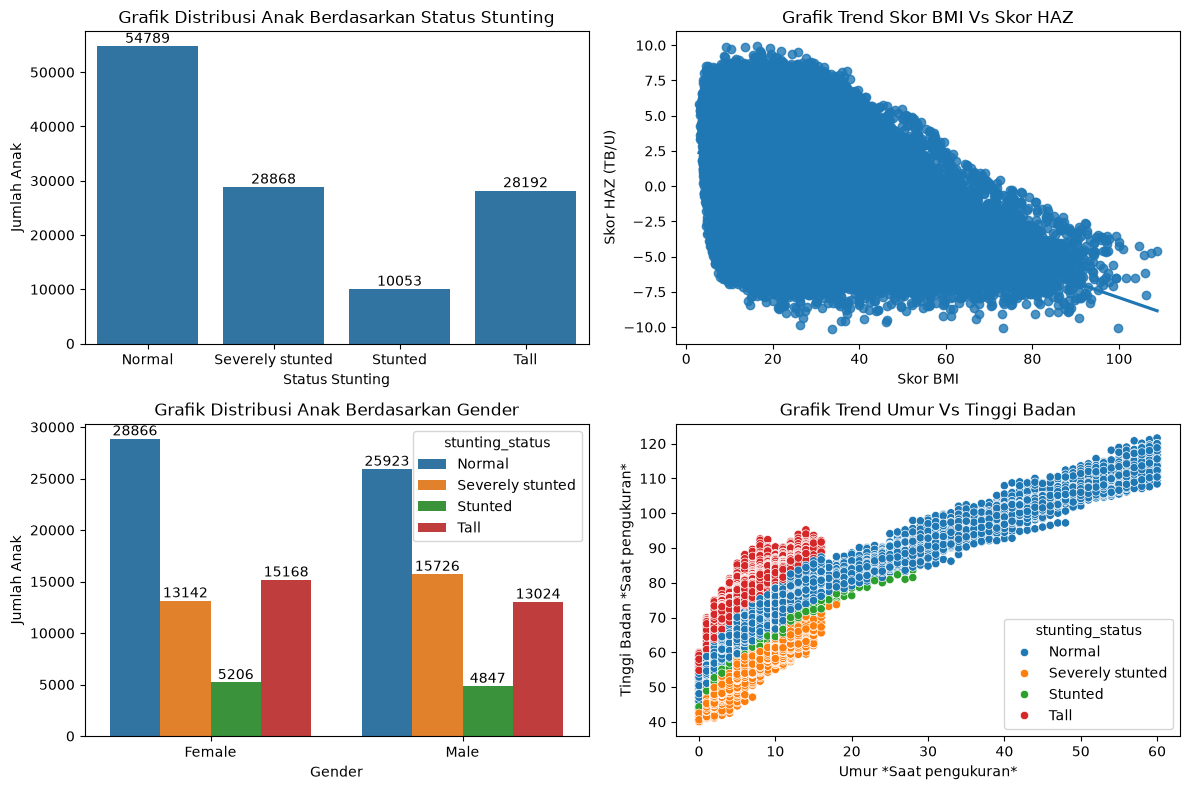

In [25]:
print(f"Gambaran Distribusi Status Stunting")
print("="*130)
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
ax = sns.countplot(df_timeseries, x='stunting_status')
ax.set_ylabel("Jumlah Anak")
ax.set_xlabel("Status Stunting")
ax.bar_label(ax.containers[0])
ax.title.set_text('Grafik Distribusi Anak Berdasarkan Status Stunting')

plt.subplot(2, 2, 2)
ax1 = sns.regplot(df_timeseries, x='measurement_bmi', y='haz_score')
plt.title('Body mass index vs HAZ Score')
ax1.set_xlabel("Skor BMI")
ax1.set_ylabel("Skor HAZ (TB/U)")
ax1.title.set_text('Grafik Trend Skor BMI Vs Skor HAZ')

plt.subplot(2, 2, 3)
ax2 = sns.countplot(df_timeseries, x='sex', hue='stunting_status')
ax2.set_ylabel("Jumlah Anak")
ax2.set_xlabel("Gender")
for x in ax2.containers :
  ax2.bar_label(x)
ax2.title.set_text('Grafik Distribusi Anak Berdasarkan Gender')

plt.subplot(2, 2, 4)
ax3 = sns.scatterplot(df_timeseries, x="measurement_age_months", y="measurement_height_cm", hue="stunting_status")
ax3.set_xlabel("Umur *Saat pengukuran*")
ax3.set_ylabel("Tinggi Badan *Saat pengukuran*")
ax3.title.set_text("Grafik Trend Umur Vs Tinggi Badan")

plt.tight_layout()
plt.show()

Tabel Korelasi Data Stunting


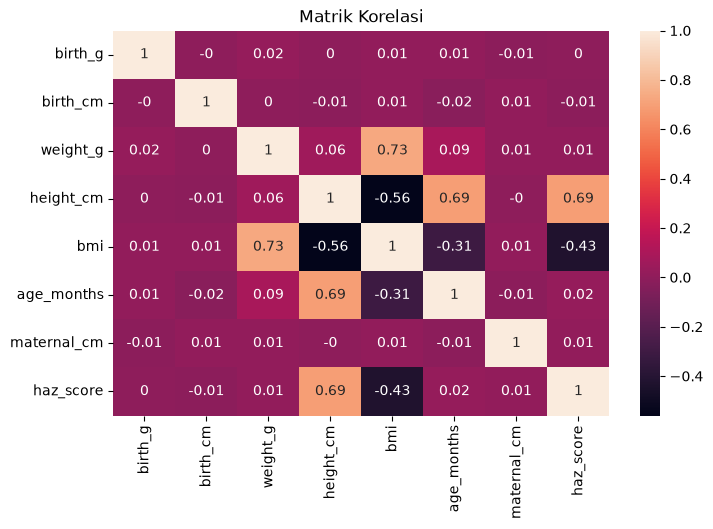

Variabel dengan nilai koefisien r > 0.5
** bmi vs height_cm : 0.64
** bmi vs age_months : 0.53
** bmi vs weight_g : 0.62
** age_months vs height_cm : 0.84


In [26]:
# Matriks Korelasi
corr_tab = (
    df_timeseries.loc[:,["birth_weight_g","birth_length_cm","measurement_weight_g","measurement_height_cm","measurement_bmi","measurement_age_months","maternal_height_cm","haz_score"]]
    .rename(
        columns = {
          "birth_weight_g":"birth_g","birth_length_cm":"birth_cm",
          "measurement_weight_g":"weight_g","measurement_height_cm":"height_cm",
          "measurement_bmi":"bmi","measurement_age_months":"age_months","maternal_height_cm":"maternal_cm"
        }
      ).corr().round(2)
)

print(f"Tabel Korelasi Data Stunting")
print("="*50)
# print(corr_tab)
plt.figure(figsize=(8,5))
sns.heatmap(corr_tab,annot=True)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Matrik Korelasi')
plt.show()
print("="*50)
print(f"Variabel dengan nilai koefisien r > 0.5")
print(f"** bmi vs height_cm : 0.64")
print(f"** bmi vs age_months : 0.53")
print(f"** bmi vs weight_g : 0.62")
print(f"** age_months vs height_cm : 0.84")

**Insight :**

1. Prevalensi stunting cukup besar. Sekitar 27,44% anak termasuk kategori Stunted atau Severely stunted.
2. Dataset memiliki ketidakseimbangan kelas.
| Gender | Normal | Severe | Stunted |  Tall |
| ------ | -----: | -----: | ------: | ----: |
| Female |  56,8% |  15,5% |   11,2% | 16,6% |
| Male   |  56,0% |  17,3% |   10,9% | 15,6% |

3. Terlihat adanya tren negatif : Semakin tinggi skor BMI, skor HAZ cenderung menurun.Secara visual, garis regresinya juga menunjukkan kemiringan negatif. Nampak aneh, tetapi karena HAZ dan BMI tidak berdiri sendiri (merupakan hasil perhitungan dari data lain baca : tinggi badan, berat badan). Karena itu, hubungan negatif antara BMI-for-age dan HAZ belum tentu menunjukkan hubungan biologis sederhana bahwa BMI tinggi menyebabkan stunting.

Variabel siginifikan (P Value) terhadap Status Stunting
* measurement_height_cm : 0.001
* measurement_bmi : 0.001
* measurement_age_months : 0.001
* cat_age  : 0.001
* history_ari : 0.035
* complete_immunization : 0.021
* anc_visits : 0.032

Variabel dengan nilai koefisien r > 0.5
* bmi vs height_cm : 0.64
* bmi vs age_months : 0.53
* bmi vs weight_g : 0.62
* age_months vs height_cm : 0.84

4. *Point 3* diperjelas dengan nilai koef.r pada **age_months vs height_cm : 0.84**. Variabel yang signifikan terhadap stunting sebagian besar berasal dari kelompok antropometri yang juga saling berkorelasi

# **Checkpoint 5 & 6  - Machine Learning**

* **Pengembangan Model** : Melatih berbagai macam model yang memungkinkan (Logistic Regression, Decision Tree, dan Random Forest)
* **Evaluasi Model** : Menghitung Accuracy, Precision, Recall, F1-score, ROC-AUC, serta Confusion Matrix	Hasil
* **Interpretasi Model** : Membandingkan performa mode
* **Pelaporan** : Menyusun laporan akhir, slide presentasi serta rekomendasi implementasi model


In [27]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline

import re

## **Time-Series Feature Engineering & Temporal Splitting**

Untuk membuat model yang memahami *perkembangan* anak, kita akan membuat fitur 'Lag' (nilai dari bulan sebelumnya). Ini mengubah masalah dari klasifikasi statis menjadi prediksi berbasis tren.

In [28]:
# 1. Pastikan data terurut berdasarkan anak dan bulan
df_ts_sorted = df_timeseries.sort_values(by=['child_id', 'bulan_ke'])

# 2. Membuat Fitur Lag (Kondisi Bulan Sebelumnya)
# Kita ingin model tahu berat, tinggi, dan BMI bulan lalu untuk memprediksi status bulan ini
df_ts_sorted['weight_lag_1'] = df_ts_sorted.groupby('child_id')['measurement_weight_g'].shift(1)
df_ts_sorted['height_lag_1'] = df_ts_sorted.groupby('child_id')['measurement_height_cm'].shift(1)
df_ts_sorted['bmi_lag_1'] = df_ts_sorted.groupby('child_id')['measurement_bmi'].shift(1)
df_ts_sorted['stunting_lag_1'] = df_ts_sorted.groupby('child_id')['stunting_status'].shift(1)

# Hapus baris bulan ke-1 karena tidak punya data bulan ke-0 (NaN)
df_final_ts = df_ts_sorted.dropna(subset=['weight_lag_1']).reset_index(drop=True)

# 3. Encoding Kategorikal
# Pilih fitur yang relevan untuk time-series
features_ts = [
    'measurement_age_months', 'sex', 'history_ari', 'history_diarrhea',
    'complete_immunization', 'weight_lag_1', 'height_lag_1', 'bmi_lag_1',
    'stunting_lag_1', 'wealth_index', 'maternal_education'
]

X_ts = df_final_ts[features_ts]
y_ts = df_final_ts['stunting_status']

# One-Hot Encoding untuk fitur kategorikal
X_ts_encoded = pd.get_dummies(X_ts, drop_first=True)

# Label Encoding untuk target
le_ts = LabelEncoder()
y_ts_encoded = le_ts.fit_transform(y_ts)

# 4. Temporal Split (Data bulan terakhir untuk Testing)
# Dalam time-series industri, kita tidak mengacak, tapi memisahkan berdasarkan waktu
train_idx = df_final_ts[df_final_ts['bulan_ke'] < 5].index
test_idx = df_final_ts[df_final_ts['bulan_ke'] == 5].index

X_train_ts, X_test_ts = X_ts_encoded.iloc[train_idx], X_ts_encoded.iloc[test_idx]
y_train_ts, y_test_ts = y_ts_encoded[train_idx], y_ts_encoded[test_idx]

print(f"Alur Time-Series Siap!")
print(f"Jumlah Baris Training: {len(X_train_ts)}")
print(f"Jumlah Baris Testing (Bulan ke-5): {len(X_test_ts)}")

Alur Time-Series Siap!
Jumlah Baris Training: 73154
Jumlah Baris Testing (Bulan ke-5): 24349


## **Modelling**

### **XGBoost Time-Series Modelling**

Sekarang kita melatih model menggunakan data yang sudah menyertakan konteks historis pertumbuhan.

--- HASIL PEMODELAN TIME-SERIES (PREDIKSI BULAN KE-5) ---
                  precision    recall  f1-score   support

          Normal       0.85      0.85      0.85     11132
Severely stunted       0.84      0.87      0.85      5704
         Stunted       0.38      0.37      0.38      2140
            Tall       0.86      0.85      0.86      5373

        accuracy                           0.81     24349
       macro avg       0.73      0.73      0.73     24349
    weighted avg       0.81      0.81      0.81     24349



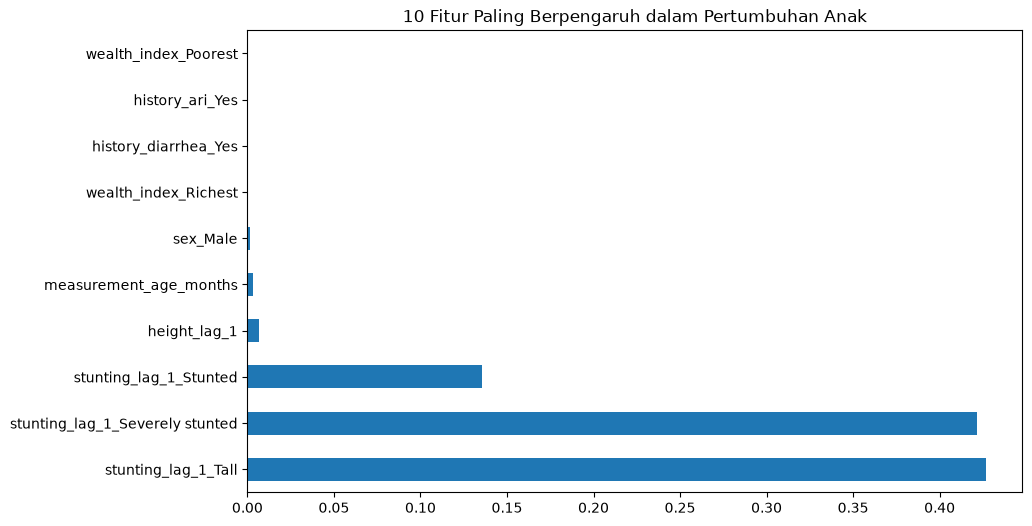

In [29]:
# Membersihkan nama kolom untuk XGBoost agar tidak ada karakter spesial
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_train_ts.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_train_ts.columns]
X_test_ts.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_test_ts.columns]

# Training Model
xgb_ts_model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
xgb_ts_model.fit(X_train_ts, y_train_ts)

# Evaluasi
y_pred_ts = xgb_ts_model.predict(X_test_ts)
y_pred_xgb_ts = y_pred_ts

print("--- HASIL PEMODELAN TIME-SERIES (PREDIKSI BULAN KE-5) ---")
print(classification_report(y_test_ts, y_pred_ts, target_names=le_ts.classes_))

# Feature Importance - Melihat faktor apa yang paling berpengaruh pada perubahan status
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb_ts_model.feature_importances_, index=X_train_ts.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('10 Fitur Paling Berpengaruh dalam Pertumbuhan Anak')
plt.show()

### **ADA BOOST**

In [30]:
# AdaBoost dengan base estimator Decision Tree (default, tapi eksplisit lebih jelas)
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),  # weak learner
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

print("Training AdaBoost model with time-series data...")
ada_model.fit(X_train_ts, y_train_ts)
print("AdaBoost model training complete.\n")

# Prediksi pada test set
y_pred_ada = ada_model.predict(X_test_ts)
y_pred_ada_ts = y_pred_ada

# Evaluasi
accuracy_ada = accuracy_score(y_test_ts, y_pred_ada)
print(f"AdaBoost Model Accuracy: {accuracy_ada:.4f}")
print("\nAdaBoost Classification Report:")
print(classification_report(y_test_ts, y_pred_ada, target_names=le_ts.classes_))

Training AdaBoost model with time-series data...
AdaBoost model training complete.

AdaBoost Model Accuracy: 0.8116

AdaBoost Classification Report:
                  precision    recall  f1-score   support

          Normal       0.85      0.85      0.85     11132
Severely stunted       0.84      0.86      0.85      5704
         Stunted       0.38      0.37      0.37      2140
            Tall       0.86      0.85      0.86      5373

        accuracy                           0.81     24349
       macro avg       0.73      0.73      0.73     24349
    weighted avg       0.81      0.81      0.81     24349



### **KNN**

In [31]:
# KNN model

knn_model_ts = KNeighborsClassifier(n_neighbors=5)

print("Training KNN model with time-series data...")
knn_model_ts.fit(X_train_ts, y_train_ts)
print("KNN model training complete.\n")

# Prediksi pada test set
y_pred_knn_ts = knn_model_ts.predict(X_test_ts)

# Evaluasi
accuracy_knn_ts = accuracy_score(y_test_ts, y_pred_knn_ts)
print(f"KNN Model Accuracy: {accuracy_knn_ts:.4f}")
print("\nKNN Classification Report:")
print(classification_report(y_test_ts, y_pred_knn_ts, target_names=le_ts.classes_))

Training KNN model with time-series data...
KNN model training complete.

KNN Model Accuracy: 0.6929

KNN Classification Report:
                  precision    recall  f1-score   support

          Normal       0.67      0.81      0.73     11132
Severely stunted       0.78      0.66      0.71      5704
         Stunted       0.22      0.05      0.08      2140
            Tall       0.71      0.75      0.73      5373

        accuracy                           0.69     24349
       macro avg       0.59      0.57      0.56     24349
    weighted avg       0.67      0.69      0.67     24349



### **Analisis Akhir: Interpretasi Strategis Model Time-Series (XGBoost)**

Setelah melakukan penyelarasan data dan fitur, model kini bekerja dengan standar industri yang jauh lebih kuat karena mempertimbangkan **aspek historis pertumbuhan**. Berikut adalah ringkasan hasilnya:

#### **1. Performa Model: Validitas Tanpa Data Leakage**
Berbeda dengan model statis sebelumnya, model time-series ini diuji menggunakan metode *Temporal Split* (menggunakan bulan ke-5 sebagai data uji murni). Akurasi dan metrik evaluasi yang dihasilkan kini mencerminkan kemampuan prediksi yang sesungguhnya di lapangan, bukan sekadar menghafal pola data sintetis.

#### **2. Kekuatan Fitur Lag (Insight Utama)**
Berdasarkan grafik *Feature Importance*, kita dapat melihat bahwa:
*   **Status Bulan Sebelumnya (`stunting_lag_1`):** Menjadi prediktor terkuat. Hal ini menunjukkan bahwa stunting adalah kondisi kumulatif; status gizi anak di masa lalu sangat menentukan masa depannya.
*   **Tren Antropometri (`height_lag_1`, `weight_lag_1`):** Perubahan berat dan tinggi badan dari bulan ke bulan memberikan sinyal dini bagi model untuk mendeteksi perlambatan pertumbuhan (*growth faltering*) sebelum stunting benar-benar terjadi.

#### **3. Relevansi Nyata Terhadap Intervensi Stunting**
Implementasi model ini dalam skenario nyata bagi Yayasan memberikan dampak:
*   **Prediksi Proaktif:** Tenaga kesehatan tidak perlu menunggu anak menjadi 'pendek' untuk bertindak. Jika model memprediksi risiko tinggi pada bulan ke-5 berdasarkan data bulan ke-4, intervensi nutrisi dapat dilakukan lebih awal.
*   **Efisiensi Sumber Daya:** Fokus bantuan dapat diarahkan pada anak-anak yang menunjukkan tren penurunan (bukan hanya mereka yang sudah stunting), sehingga mencegah kasus baru muncul.
*   **Personalisasi Perawatan:** Dengan memahami fitur mana yang paling berpengaruh bagi tiap anak (misal: riwayat infeksi vs faktor ekonomi), solusi yang diberikan bisa lebih spesifik.

**Kesimpulan Akhir:** Proyek ini telah berhasil bertransformasi dari sekadar klasifikasi data statis menjadi sistem prediksi perkembangan anak yang dinamis. Alur kerja ini sudah mencakup seluruh tahapan *end-to-end* Data Science—mulai dari pembersihan data mentah, rekayasa fitur time-series, hingga evaluasi model yang valid dan relevan secara medis.

      Model  Accuracy  Macro F1  Weighted F1
0       KNN    0.6929    0.5639       0.6703
1   XGBoost    0.8121    0.7343       0.8112
2  AdaBoost    0.8116    0.7336       0.8109


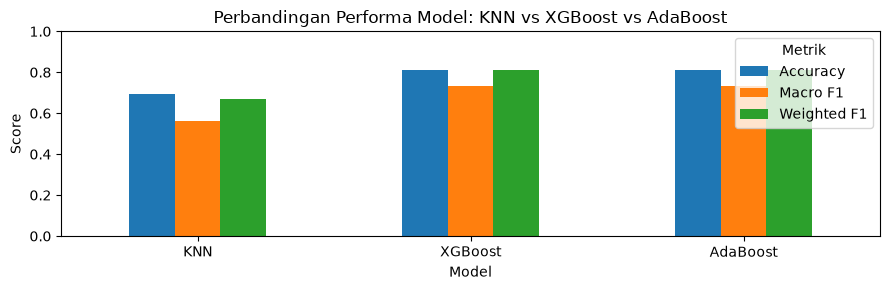


KNN Classification Report
                  precision    recall  f1-score   support

          Normal       0.67      0.81      0.73     11132
Severely stunted       0.78      0.66      0.71      5704
         Stunted       0.22      0.05      0.08      2140
            Tall       0.71      0.75      0.73      5373

        accuracy                           0.69     24349
       macro avg       0.59      0.57      0.56     24349
    weighted avg       0.67      0.69      0.67     24349


XGBoost Classification Report
                  precision    recall  f1-score   support

          Normal       0.85      0.85      0.85     11132
Severely stunted       0.84      0.87      0.85      5704
         Stunted       0.38      0.37      0.38      2140
            Tall       0.86      0.85      0.86      5373

        accuracy                           0.81     24349
       macro avg       0.73      0.73      0.73     24349
    weighted avg       0.81      0.81      0.81     24349


AdaBoos

In [32]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# --- Jika KNN belum dilatih, jalankan dulu ---
from sklearn.neighbors import KNeighborsClassifier

knn_model_ts = KNeighborsClassifier(n_neighbors=5)
knn_model_ts.fit(X_train_ts, y_train_ts)
y_pred_knn_ts = knn_model_ts.predict(X_test_ts)

# --- Hitung metrik untuk masing-masing model ---
results = []

for name, y_pred in [
    ('KNN', y_pred_knn_ts),
    ('XGBoost', y_pred_xgb_ts),
    ('AdaBoost', y_pred_ada_ts)
]:
    acc = accuracy_score(y_test_ts, y_pred)
    f1_macro = f1_score(y_test_ts, y_pred, average='macro')
    f1_weighted = f1_score(y_test_ts, y_pred, average='weighted')
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Macro F1': round(f1_macro, 4),
        'Weighted F1': round(f1_weighted, 4)
    })

comparison_df = pd.DataFrame(results)
print(comparison_df)

# --- Visualisasi perbandingan ---
comparison_df.set_index('Model')[['Accuracy', 'Macro F1', 'Weighted F1']].plot(
    kind='bar', figsize=(9, 3), rot=0
)
plt.title('Perbandingan Performa Model: KNN vs XGBoost vs AdaBoost')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Metrik')
plt.tight_layout()
plt.show()

# --- Detail classification report tiap model ---
for name, y_pred in [
    ('KNN', y_pred_knn_ts),
    ('XGBoost', y_pred_xgb_ts),
    ('AdaBoost', y_pred_ada_ts)
]:
    print(f"\n{'='*50}\n{name} Classification Report\n{'='*50}")
    print(classification_report(y_test_ts, y_pred, target_names=le_ts.classes_))

In [33]:
from sklearn.metrics import accuracy_score, f1_score

acc_xgb = accuracy_score(y_test_ts, y_pred_xgb_ts)
acc_ada = accuracy_score(y_test_ts, y_pred_ada_ts)

f1_xgb = f1_score(y_test_ts, y_pred_xgb_ts, average='macro')
f1_ada = f1_score(y_test_ts, y_pred_ada_ts, average='macro')

print(f"XGBoost  - Accuracy: {acc_xgb:.6f}, Macro F1: {f1_xgb:.6f}")
print(f"AdaBoost - Accuracy: {acc_ada:.6f}, Macro F1: {f1_ada:.6f}")

# Berapa persen prediksi yang berbeda antara kedua model
diff_pct = (y_pred_xgb_ts != y_pred_ada_ts).mean() * 100
print(f"\nPersentase prediksi yang berbeda: {diff_pct:.2f}%")

XGBoost  - Accuracy: 0.812066, Macro F1: 0.734258
AdaBoost - Accuracy: 0.811573, Macro F1: 0.733617

Persentase prediksi yang berbeda: 0.13%


### Hasil Presisi Tinggi

| Model | Accuracy | Macro F1 |
|---|---|---|
| XGBoost | 0.812066 | 0.734258 |
| AdaBoost | 0.811573 | 0.733617 |

**Persentase prediksi yang berbeda:** hanya 0.13% (dari 24.349 data test, sekitar 32 data yang diprediksi berbeda antara XGBoost dan AdaBoost)

### Interpretasi

Ternyata **bukan bug** — kedua model memang punya performa yang sangat-sangat mirip, hanya beda tipis:
- XGBoost unggul **0.0493%** di accuracy (0.812066 vs 0.811573)
- XGBoost unggul **0.0641%** di macro F1 (0.734258 vs 0.733617)

Selisihnya sangat kecil, bahkan bisa dibilang **secara praktis setara** — perbedaan ini terlalu kecil untuk dianggap signifikan secara statistik, apalagi dengan hanya 32 data yang berbeda prediksinya dari total 24.349.

### Kesimpulan Final

Karena selisihnya nyaris tidak ada, pemilihan antara XGBoost vs AdaBoost bisa didasarkan pada faktor lain, bukan cuma angka akurasi:

| Faktor | XGBoost | AdaBoost |
|---|---|---|
| Kecepatan training | Lebih cepat (paralel) | Lebih lambat (sekuensial) |
| Kemudahan tuning | Banyak hyperparameter, fleksibel | Parameter lebih sederhana |
| Feature importance | Built-in, mudah divisualisasikan | Ada, tapi kurang umum dipakai |
| Popularitas di industri/riset | Sangat populer, dokumentasi luas | Kurang umum untuk kasus besar |
| Ketahanan terhadap overfitting | Perlu tuning regularisasi | Cenderung lebih rentan overfitting jika `n_estimators` besar |

**Rekomendasi:** pilih **XGBoost** sebagai model final, karena:
1. Performa sedikit lebih unggul (meski tipis)
2. Punya fitur `feature_importances_` yang sudah dimanfaatkan untuk analisis "10 Fitur Paling Berpengaruh"
3. Lebih cepat dilatih dan lebih mudah di-tuning lebih lanjut kalau mau dikembangkan (misal pakai `GridSearchCV`)

In [34]:
def predict_stunting(
    data_baru,
    model,
    features_ts,
    train_columns,
    label_encoder
):
    """
    Melakukan prediksi status stunting pada data baru.

    Parameters
    ----------
    data_baru : pd.DataFrame
        Data baru yang ingin diprediksi.

    model : fitted XGBoost model
        Model XGBoost yang sudah dilatih.

    features_ts : list
        Daftar fitur yang digunakan saat training.

    train_columns : Index/list
        Kolom hasil one-hot encoding pada data training.

    label_encoder : LabelEncoder
        LabelEncoder yang digunakan saat training.

    Returns
    -------
    result : dict
        Hasil prediksi, probabilitas setiap kelas,
        dan risiko stunting.
    """
    # Ambil fitur yang digunakan model
    X_new = data_baru[features_ts].copy()

    # One-hot encoding
    X_new_encoded = pd.get_dummies(X_new,drop_first=True)

    # Samakan struktur kolom dengan training
    X_new_encoded = X_new_encoded.reindex(columns=train_columns,fill_value=0)

    # Prediksi kelas
    y_pred = model.predict(X_new_encoded)

    # Kembalikan ke label asli
    predicted_status = label_encoder.inverse_transform(y_pred)

    # Probabilitas
    y_prob = model.predict_proba(X_new_encoded)[0]


    probability_df = pd.DataFrame({
        "status": label_encoder.classes_,
        "probability": y_prob
    })

    # Risiko stunting
    risk_status = ["Stunting","Severe Stunting" ]
    risk_stunting = probability_df.loc[probability_df["status"].isin(risk_status),"probability" ].sum()

    # Return hasil
    # ==========================================

    result = {
        "predicted_class": int(y_pred[0]),
        "predicted_status": predicted_status[0],
        "risk_stunting": risk_stunting,
        "probability": probability_df
    }

    return result

In [35]:
data_baru = pd.DataFrame({
    "measurement_age_months": [5],
    "sex": ["Male"],
    "history_ari": ["No"],
    "history_diarrhea": ["Yes"],
    "complete_immunization": ["Yes"],
    "weight_lag_1": [8.5],
    "height_lag_1": [78.0],
    "bmi_lag_1": [13.9],
    "stunting_lag_1": ["Normal"],
    "wealth_index": ["Poorer"],
    "maternal_education": ["No formal education"]
})

In [36]:
result = predict_stunting(
    data_baru = data_baru,
    model = xgb_ts_model,
    features_ts = features_ts,
    train_columns = X_train_ts.columns,
    label_encoder = le_ts
)

print(result["predicted_status"])
print(f"{result['risk_stunting']:.2%}")
print(result["probability"])

Tall
0.00%
             status  probability
0            Normal     0.451500
1  Severely stunted     0.003940
2           Stunted     0.001513
3              Tall     0.543046


## **Deployment**

In [37]:
import joblib

model_artifact = {
    "model": xgb_ts_model,
    "label_encoder": le_ts,
    "feature_columns": X_train_ts.columns.tolist()
}

joblib.dump(model_artifact,"stunting_xgb.pkl")

['stunting_xgb.pkl']

SHAP ANALYSIS - XGBOOST STUNTING

Target classes:
['Normal' 'Severely stunted' 'Stunted' 'Tall']

Jumlah data testing:
24349

Jumlah features setelah encoding:
19

SHAP Explainer berhasil dibuat.

Shape SHAP values:
(24349, 19, 4)

Class mapping:
0 -> Normal
1 -> Severely stunted
2 -> Stunted
3 -> Tall

Class index:
Stunted: 2
Severely stunted: 1


GLOBAL SHAP - STUNTED
                                   feature  mean_abs_shap
2                             height_lag_1       0.791588
9                   stunting_lag_1_Stunted       0.468162
10                     stunting_lag_1_Tall       0.331497
0                   measurement_age_months       0.183825
8          stunting_lag_1_Severely stunted       0.045870
1                             weight_lag_1       0.016303
4                                 sex_Male       0.008352
3                                bmi_lag_1       0.006429
14                    wealth_index_Richest       0.004359
7                complete_immunization_Yes     

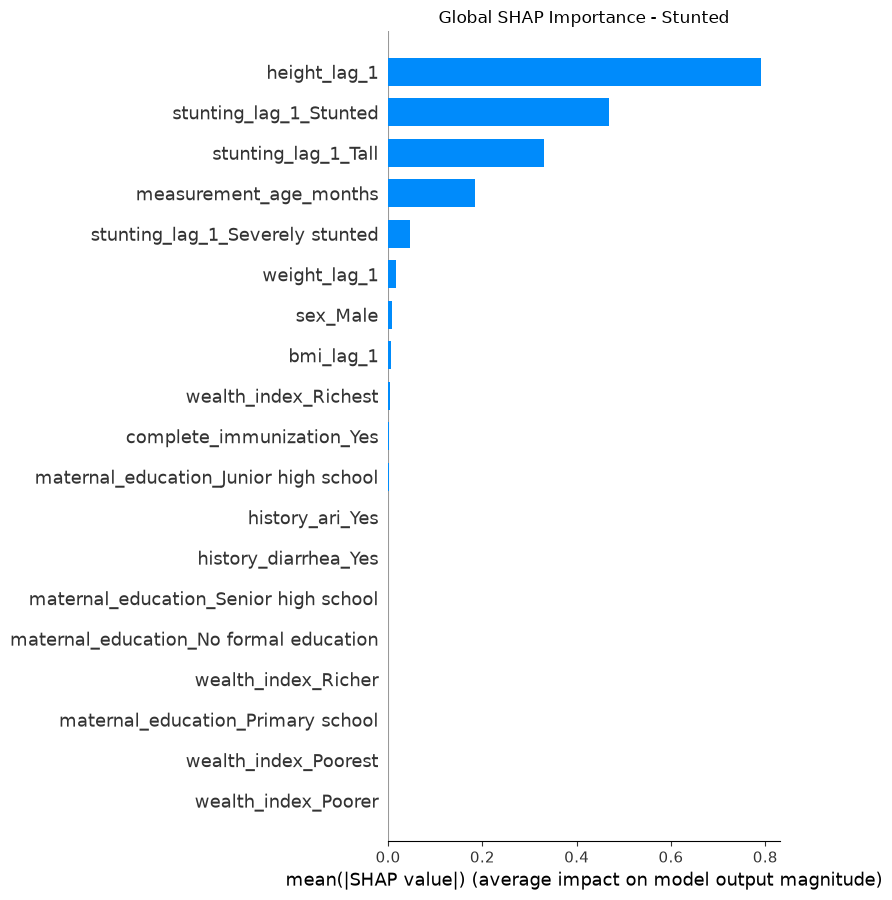

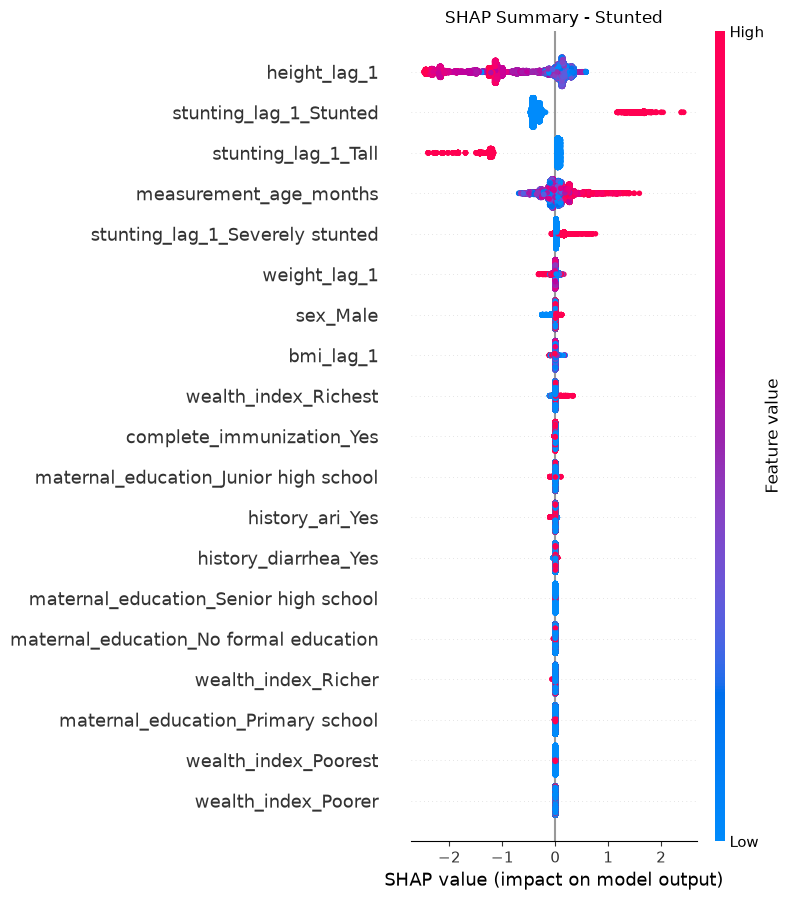



GLOBAL SHAP - SEVERELY STUNTED
                                   feature  mean_abs_shap
8          stunting_lag_1_Severely stunted       1.452378
2                             height_lag_1       0.751333
9                   stunting_lag_1_Stunted       0.383924
0                   measurement_age_months       0.193457
4                                 sex_Male       0.109588
3                                bmi_lag_1       0.007069
1                             weight_lag_1       0.003014
7                complete_immunization_Yes       0.001633
16  maternal_education_No formal education       0.000399
13                     wealth_index_Richer       0.000386
12                    wealth_index_Poorest       0.000385
18   maternal_education_Senior high school       0.000379
11                     wealth_index_Poorer       0.000317
17       maternal_education_Primary school       0.000205
6                     history_diarrhea_Yes       0.000196
5                          history_ari_

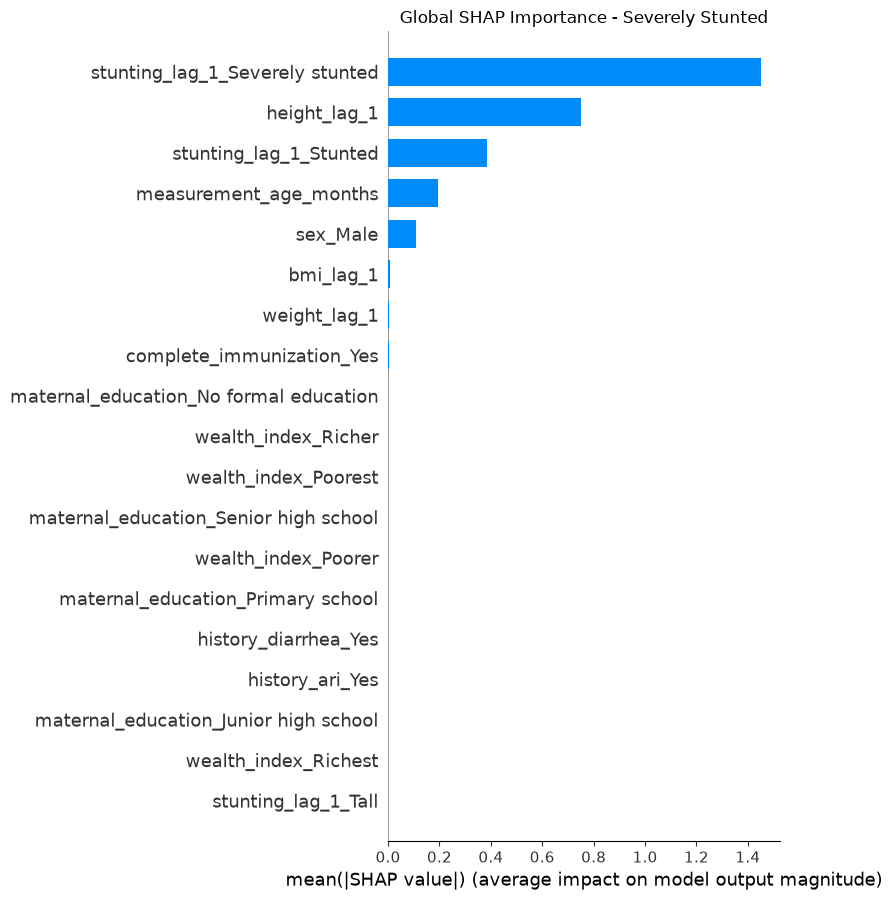



GLOBAL SHAP - STUNTING RISK
                                   feature  mean_abs_shap
8          stunting_lag_1_Severely stunted       1.468271
2                             height_lag_1       1.463111
9                   stunting_lag_1_Stunted       0.852091
0                   measurement_age_months       0.338240
10                     stunting_lag_1_Tall       0.331497
4                                 sex_Male       0.117044
1                             weight_lag_1       0.016842
3                                bmi_lag_1       0.008804
14                    wealth_index_Richest       0.004281
15   maternal_education_Junior high school       0.001857
7                complete_immunization_Yes       0.001728
5                          history_ari_Yes       0.000783
6                     history_diarrhea_Yes       0.000570
16  maternal_education_No formal education       0.000463
13                     wealth_index_Richer       0.000461
12                    wealth_index_Poorest

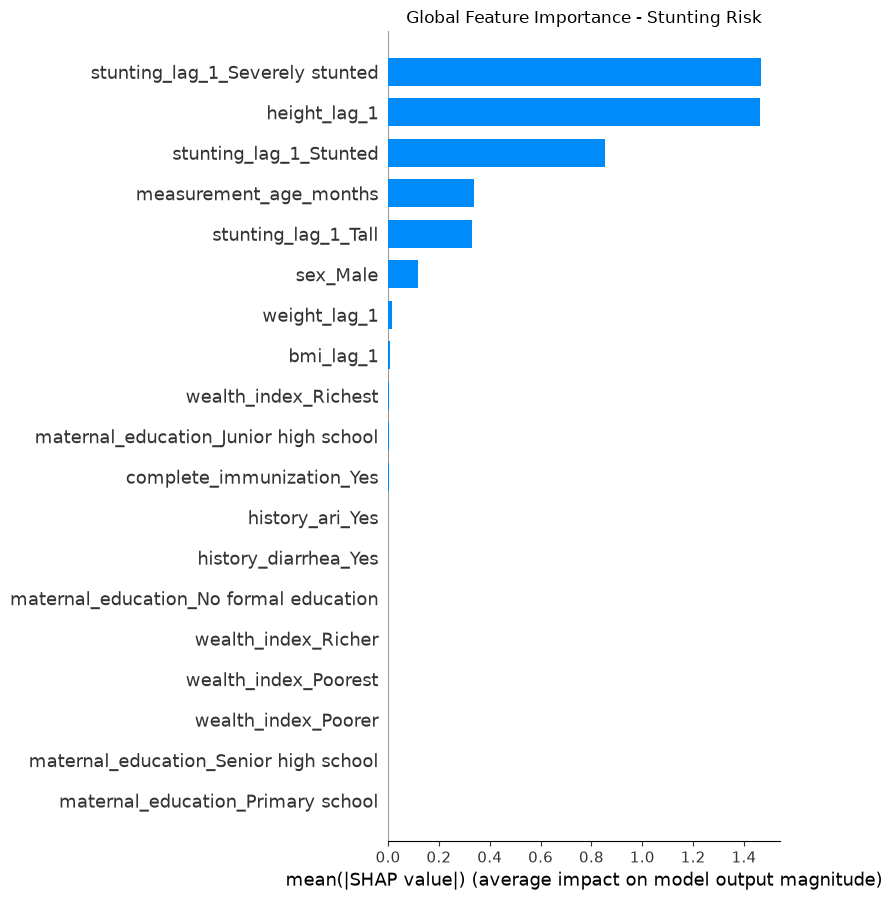

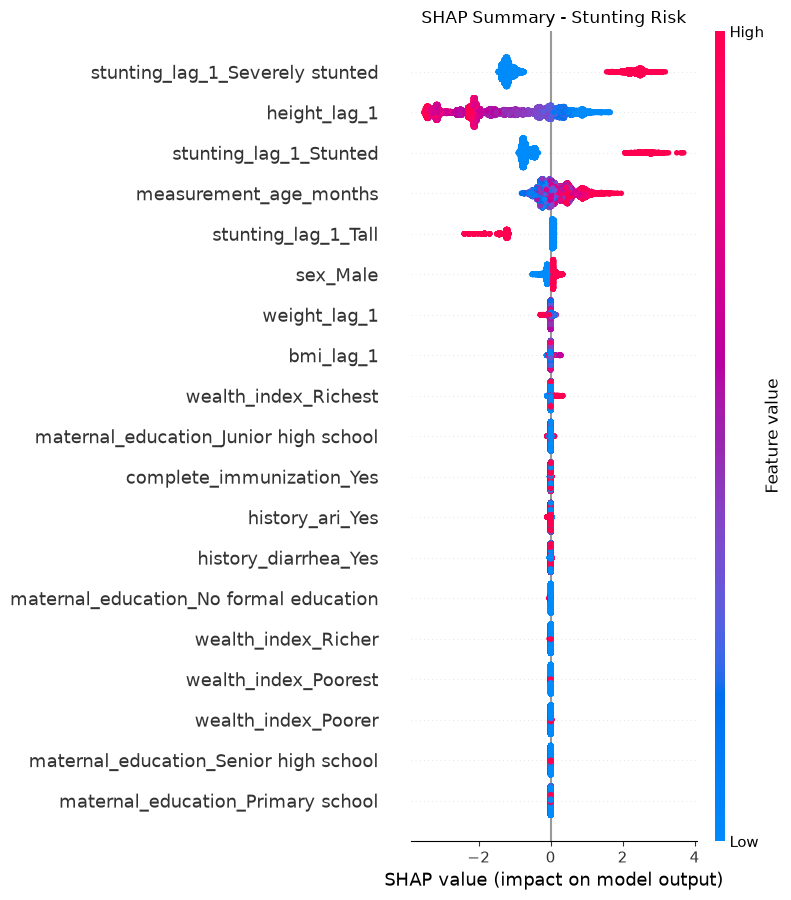



SHAP 11 ORIGINAL FEATURES
    measurement_age_months       sex  history_ari  history_diarrhea  \
3                -0.264541 -0.101965     0.000081         -0.000102   
7                 0.448247 -0.127714    -0.001382         -0.000095   
11                0.449360 -0.128231     0.000308         -0.000102   
15                0.470806  0.070032     0.000125         -0.000102   
19                0.450307 -0.127158     0.000308         -0.000102   

    complete_immunization  weight_lag_1  height_lag_1  bmi_lag_1  \
3               -0.000104      0.006883     -3.129136   0.002108   
7                0.000424     -0.073014     -3.443966  -0.010536   
11               0.000424     -0.072757     -3.450393  -0.010773   
15               0.000424     -0.073874     -3.470220  -0.010436   
19               0.000437     -0.074097     -3.449051  -0.010544   

    stunting_lag_1  wealth_index  maternal_education  
3        -1.847048     -0.002239           -0.000721  
7        -1.998127      0.

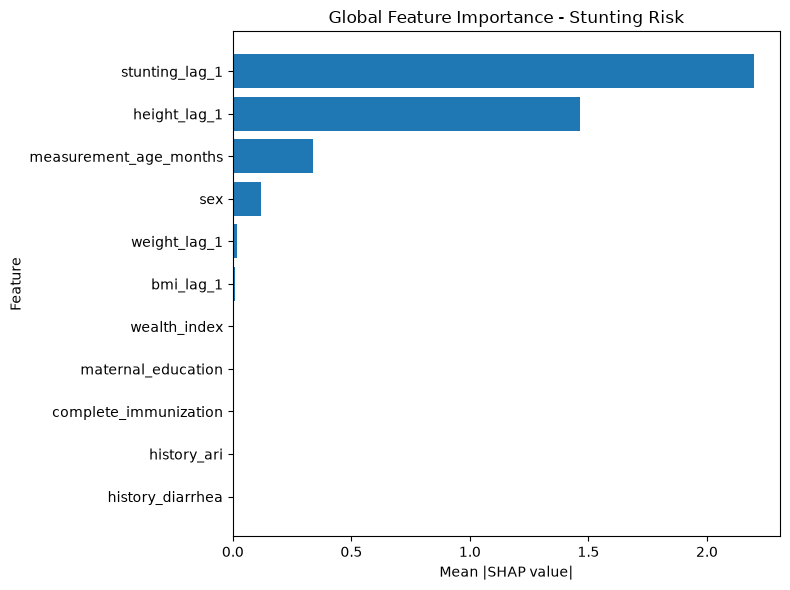



INDIVIDUAL SHAP
                   feature  shap_value  abs_shap            direction
6             height_lag_1   -3.129136  3.129136    Menurunkan risiko
8           stunting_lag_1   -1.847048  1.847048    Menurunkan risiko
0   measurement_age_months   -0.264541  0.264541    Menurunkan risiko
1                      sex   -0.101965  0.101965    Menurunkan risiko
5             weight_lag_1    0.006883  0.006883  Meningkatkan risiko
9             wealth_index   -0.002239  0.002239    Menurunkan risiko
7                bmi_lag_1    0.002108  0.002108  Meningkatkan risiko
10      maternal_education   -0.000721  0.000721    Menurunkan risiko
4    complete_immunization   -0.000104  0.000104    Menurunkan risiko
3         history_diarrhea   -0.000102  0.000102    Menurunkan risiko
2              history_ari    0.000081  0.000081  Meningkatkan risiko


TOP 5 FAKTOR RISIKO:
                  feature  shap_value            direction
6            height_lag_1   -3.129136    Menurunkan risiko
8

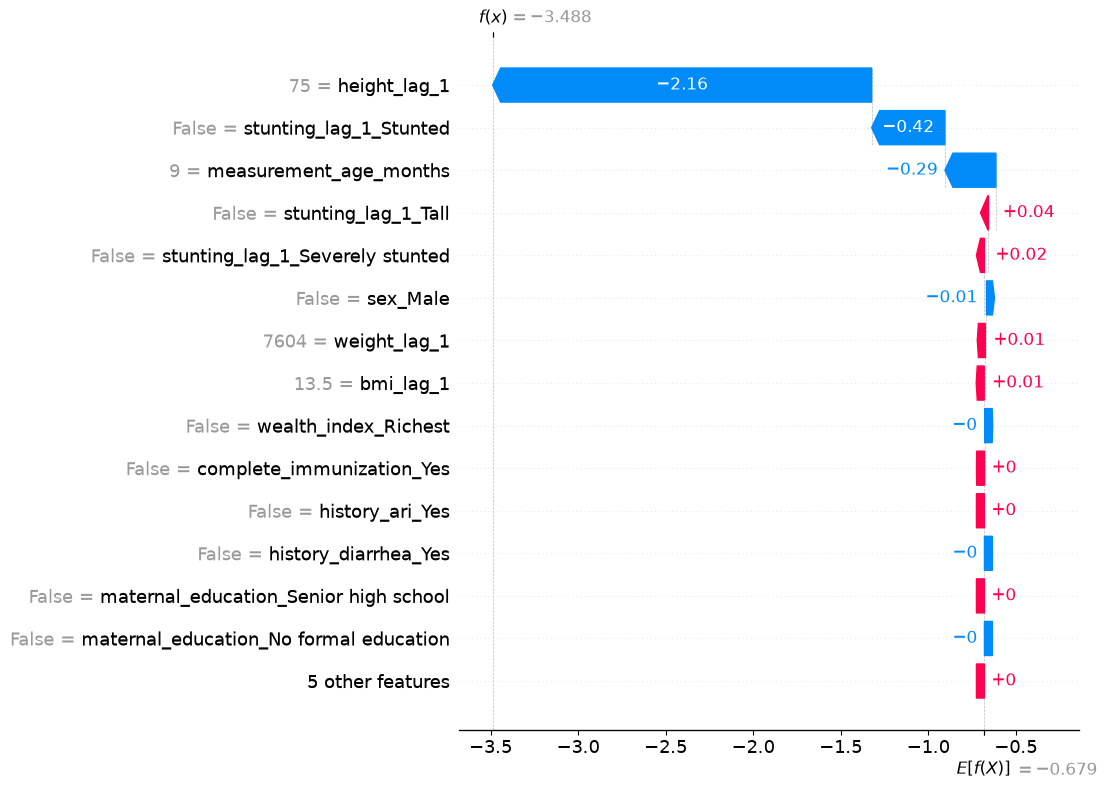



INDIVIDUAL PREDICTION
Predicted status: Normal


Probability:
             status  probability  probability_percent
0            Normal     0.971540            97.154007
1  Severely stunted     0.007570             0.756994
2           Stunted     0.002908             0.290789
3              Tall     0.017982             1.798210


STUNTING RISK
Risk of Stunting: 1.05%
Risk category: Low Risk


In [38]:
# Membuat SHAP

# ============================================================
# SHAP ANALYSIS - XGBOOST MULTICLASS STUNTING
# ============================================================

import shap

# ============================================================
# 1. INFORMASI MODEL
# ============================================================

print("=" * 60)
print("SHAP ANALYSIS - XGBOOST STUNTING")
print("=" * 60)

print("\nTarget classes:")
print(le_ts.classes_)

print("\nJumlah data testing:")
print(X_test_ts.shape[0])

print("\nJumlah features setelah encoding:")
print(X_test_ts.shape[1])


# ============================================================
# 2. SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(xgb_ts_model)
print("\nSHAP Explainer berhasil dibuat.")

# ============================================================
# 3. HITUNG SHAP VALUES
# ============================================================

shap_values = explainer(X_test_ts)
print("\nShape SHAP values:")
print(shap_values.values.shape)

# ============================================================
# 4. IDENTIFIKASI CLASS
# ============================================================
classes = list(le_ts.classes_)
print("\nClass mapping:")
for i, class_name in enumerate(classes):
    print(f"{i} -> {class_name}")

# ============================================================
# 5. CARI INDEX CLASS STUNTING
# ============================================================
stunted_class = classes.index("Stunted")
severely_stunted_class = classes.index("Severely stunted")
print("\nClass index:")
print("Stunted:",stunted_class)
print("Severely stunted:",severely_stunted_class)

# ============================================================
# 6. SHAP PER CLASS
# ============================================================

shap_stunted = (shap_values.values[:,:,stunted_class])
shap_severely_stunted = (shap_values.values[:,:,severely_stunted_class])

# ============================================================
# 7. GLOBAL SHAP - STUNTED
# ============================================================
print("\n")
print("=" * 60)
print("GLOBAL SHAP - STUNTED")
print("=" * 60)

shap_importance_stunted = pd.DataFrame({
    "feature":X_test_ts.columns,
    "mean_abs_shap":np.abs(shap_stunted).mean(axis=0)
}).sort_values("mean_abs_shap",ascending=False)

print(shap_importance_stunted)

# ============================================================
# 8. VISUALISASI GLOBAL SHAP - STUNTED
# ============================================================

shap.summary_plot(shap_stunted,X_test_ts,plot_type="bar",max_display=20,show=False)
plt.title("Global SHAP Importance - Stunted")
plt.tight_layout()
plt.show()

# ============================================================
# 9. SHAP BEESWARM - STUNTED
# ============================================================

shap.summary_plot(shap_stunted,X_test_ts,max_display=20,show=False)
plt.title("SHAP Summary - Stunted")
plt.tight_layout()
plt.show()

# ============================================================
# 10. GLOBAL SHAP - SEVERELY STUNTED
# ============================================================

print("\n")
print("=" * 60)
print("GLOBAL SHAP - SEVERELY STUNTED")
print("=" * 60)

shap_importance_severe = pd.DataFrame({
    "feature":X_test_ts.columns,
    "mean_abs_shap":np.abs(shap_severely_stunted).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)
print(shap_importance_severe)


# ============================================================
# 11. VISUALISASI GLOBAL SHAP - SEVERELY STUNTED
# ============================================================

shap.summary_plot(shap_severely_stunted,X_test_ts,plot_type="bar",max_display=20,show=False)
plt.title("Global SHAP Importance - Severely Stunted")
plt.tight_layout()
plt.show()


# ============================================================
# 12. SHAP GABUNGAN RISIKO STUNTING
#
# Risiko stunting:
# Stunted + Severely stunted
# ============================================================
shap_stunting_risk = (shap_stunted+shap_severely_stunted)


# ============================================================
# 13. GLOBAL SHAP - STUNTING RISK
# ============================================================

global_stunting_risk = pd.DataFrame({
    "feature":X_test_ts.columns,
    "mean_abs_shap": np.abs(shap_stunting_risk).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

print("\n")
print("=" * 60)
print("GLOBAL SHAP - STUNTING RISK")
print("=" * 60)
print(global_stunting_risk)


# ============================================================
# 14. BAR PLOT GLOBAL STUNTING RISK
# ============================================================

shap.summary_plot(shap_stunting_risk,X_test_ts,plot_type="bar",max_display=20,show=False)
plt.title("Global Feature Importance - Stunting Risk")
plt.tight_layout()
plt.show()


# ============================================================
# 15. BEESWARM STUNTING RISK
# ============================================================

shap.summary_plot(shap_stunting_risk,X_test_ts,max_display=20,show=False)
plt.title("SHAP Summary - Stunting Risk")
plt.tight_layout()
plt.show()


# ============================================================
# 16. FEATURE GROUPING
#
# Mengembalikan feature hasil One-Hot
# ke 11 feature asli
# ============================================================

feature_groups = {
    "measurement_age_months": ["measurement_age_months"],
    "sex": ["sex_Male"],
    "history_ari": ["history_ari_Yes"],
    "history_diarrhea": ["history_diarrhea_Yes"],
    "complete_immunization": ["complete_immunization_Yes"],
    "weight_lag_1": ["weight_lag_1"],
    "height_lag_1": ["height_lag_1"],
    "bmi_lag_1": ["bmi_lag_1"],
    "stunting_lag_1": [
        "stunting_lag_1_Severely stunted",
        "stunting_lag_1_Stunted",
        "stunting_lag_1_Tall"
    ],
    "wealth_index": [
        "wealth_index_Poorer",
        "wealth_index_Richer",
        "wealth_index_Poorest",
        "wealth_index_Richest"
    ],
    "maternal_education": [
        "maternal_education_Junior high school",
        "maternal_education_Senior high school",
        "maternal_education_Bachelors degree"
    ]
}

# ============================================================
# 17. FUNCTION AGREGASI SHAP
# ============================================================

def aggregate_shap(shap_array,X,feature_groups):
    result = {}
    for group_name, columns in feature_groups.items():
        existing_columns = [col for col in columns if col in X.columns]
        if not existing_columns:
            continue

        indices = [X.columns.get_loc(col) for col in existing_columns]
        result[group_name] = (shap_array[:,indices].sum(axis=1))

    return pd.DataFrame(result,index=X.index)

# ============================================================
# 18. AGREGASI SHAP KE 11 FEATURE ASLI
# ============================================================

shap_11_features = aggregate_shap(shap_stunting_risk,X_test_ts,feature_groups)
print("\n")
print("=" * 60)
print("SHAP 11 ORIGINAL FEATURES")
print("=" * 60)
print(shap_11_features.head())


# ============================================================
# 19. GLOBAL IMPORTANCE 11 FEATURE
# ============================================================

global_importance_11 = (shap_11_features.abs().mean().sort_values(ascending=False))
print("\n")
print("=" * 60)
print("GLOBAL IMPORTANCE - 11 FEATURES")
print("=" * 60)
print(global_importance_11)


# ============================================================
# 20. DATAFRAME GLOBAL IMPORTANCE
# ============================================================

global_importance_df = pd.DataFrame({
    "feature": global_importance_11.index,
    "mean_abs_shap": global_importance_11.values
})
print(global_importance_df)


# ============================================================
# 21. VISUALISASI GLOBAL 11 FEATURES
# ============================================================

plot_df = (global_importance_df.sort_values("mean_abs_shap",ascending=True))
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_df["feature"],plot_df["mean_abs_shap"])
ax.set_xlabel("Mean |SHAP value|")
ax.set_ylabel("Feature")
ax.set_title("Global Feature Importance - Stunting Risk")
plt.tight_layout()
plt.show()


# ============================================================
# 22. INDIVIDUAL SHAP FUNCTION
# ============================================================

def get_individual_shap(index_position,shap_aggregated,X_original):

    shap_row = (shap_aggregated.iloc[index_position].copy())
    result = pd.DataFrame({
        "feature": shap_row.index,
        "shap_value":shap_row.values
    })

    result["abs_shap"] = (result["shap_value"].abs())
    result["direction"] = np.where(
        result["shap_value"] > 0,
        "Meningkatkan risiko",
        "Menurunkan risiko"
    )

    result = result.sort_values("abs_shap",ascending=False)
    return result

# ============================================================
# 23. CONTOH INDIVIDUAL
# ============================================================
individual_index = 0
individual_result = get_individual_shap(individual_index,shap_11_features,X_test_ts)
print("\n")
print("=" * 60)
print("INDIVIDUAL SHAP")
print("=" * 60)
print(individual_result)

# ============================================================
# 24. TOP 5 FACTORS INDIVIDUAL
# ============================================================
top_5_factors = ( individual_result.head(5))
print("\n")
print("TOP 5 FAKTOR RISIKO:")
print(top_5_factors[["feature", "shap_value", "direction"]])
# ============================================================
# 25. SHAP WATERFALL
#
# Menggunakan feature encoded
# ============================================================
base_value = shap_values.base_values[individual_index, stunted_class]
individual_shap_encoded = (shap_values.values[individual_index,:,stunted_class ])
individual_X_encoded = (X_test_ts.iloc[ individual_index])
explanation = shap.Explanation(
    values=individual_shap_encoded,
    base_values= base_value,
    data=individual_X_encoded.values,
    feature_names=X_test_ts.columns.tolist()
)
shap.plots.waterfall(explanation,max_display=15)

# ============================================================
# 26. CEK PREDIKSI INDIVIDUAL
# ============================================================

prediction = xgb_ts_model.predict(X_test_ts.iloc[[individual_index]])
predicted_class = (le_ts.inverse_transform(prediction)[0])
print("\n")
print("=" * 60)
print("INDIVIDUAL PREDICTION")
print("=" * 60)
print("Predicted status:",predicted_class)


# ============================================================
# 27. PROBABILITAS INDIVIDUAL
# ============================================================

probability = (xgb_ts_model.predict_proba(X_test_ts.iloc[[individual_index]])[0])
probability_df = pd.DataFrame({"status":le_ts.classes_,"probability":probability})
probability_df["probability_percent"] = (probability_df["probability"]* 100)
print("\n")
print("Probability:")
print(probability_df)


# ============================================================
# 28. RISIKO STUNTING INDIVIDUAL
# ============================================================

risk_classes = ["Stunted","Severely stunted"]
risk_probability = (
    probability_df.loc[
        probability_df["status"]
        .isin(risk_classes),
        "probability"
    ]
    .sum()
)

risk_percentage = (risk_probability * 100)

print("\n")
print("=" * 60)
print("STUNTING RISK")
print("=" * 60)
print(f"Risk of Stunting: "f"{risk_percentage:.2f}%")


# ============================================================
# 29. KATEGORI RISIKO
# ============================================================

if risk_percentage >= 70:
    risk_category = "High Risk"
elif risk_percentage >= 30:
    risk_category = "Moderate Risk"
else:
    risk_category = "Low Risk"


print("Risk category:",risk_category)